<a href="https://colab.research.google.com/github/Naveenkumarsinghal64/Naveen-Singhal_JECRC_CEI/blob/main/Week5_Naveen_Singhal_JECRC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

---
### ✅ This version implements all 5 Learning Tasks:
1. Replaced corpus with a custom paragraph
2. Increased embedding dimension (32 → 64)
3. Increased epochs to 200
4. Changed hidden units 64 → 128
5. Generates 10 words instead of 5

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus

### ✅ Task 1: Replace corpus with your own paragraph
Below we use a **custom paragraph about deep learning and neural networks** instead of the original tiny sample corpus. A larger, richer paragraph gives the models more patterns to learn from.

In [2]:
# ✅ TASK 1: Custom corpus (replaced the original sample corpus)
corpus = '''
deep learning is a subfield of machine learning that uses neural networks with many layers
neural networks are inspired by the structure of the human brain and its interconnected neurons
recurrent neural networks are designed to handle sequential data such as text speech and time series
a vanilla rnn struggles to remember information from many steps in the past due to vanishing gradients
lstm networks introduce input forget and output gates to control the flow of information over time
lstm helps the model remember long term dependencies in long sequences of text
gru networks simplify the lstm design by combining gates into reset and update gates
gru is faster to train than lstm and often achieves similar performance on many tasks
text generation models learn to predict the next word given the previous words in a sentence
language models can generate meaningful and coherent sentences once they are trained on enough data
deep learning models can capture grammar syntax and semantic meaning from large text corpora
training a good language model requires a large vocabulary and many diverse training examples
word embeddings represent words as dense vectors that capture semantic relationships between words
attention mechanisms allow models to focus on the most relevant parts of the input sequence
modern natural language processing relies heavily on deep learning and neural network architectures
'''
print(corpus)


deep learning is a subfield of machine learning that uses neural networks with many layers
neural networks are inspired by the structure of the human brain and its interconnected neurons
recurrent neural networks are designed to handle sequential data such as text speech and time series
a vanilla rnn struggles to remember information from many steps in the past due to vanishing gradients
lstm networks introduce input forget and output gates to control the flow of information over time
lstm helps the model remember long term dependencies in long sequences of text
gru networks simplify the lstm design by combining gates into reset and update gates
gru is faster to train than lstm and often achieves similar performance on many tasks
text generation models learn to predict the next word given the previous words in a sentence
language models can generate meaningful and coherent sentences once they are trained on enough data
deep learning models can capture grammar syntax and semantic meani

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 135
X shape: (206, 16)
y shape: (206,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

### ✅ Task 2 & 4 applied here:
- Embedding dimension increased from **32 → 64**
- Hidden units increased from **64 → 128**

In [4]:
# ✅ TASK 2: embedding dimension 32 -> 64
# ✅ TASK 4: hidden units 64 -> 128
EMBEDDING_DIM = 64
HIDDEN_UNITS = 128
EPOCHS = 200  # ✅ TASK 3: epochs 100 -> 200

rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len-1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

Uses the same updated settings: embedding=64, hidden units=128, epochs=200.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len-1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

Uses the same updated settings: embedding=64, hidden units=128, epochs=200.

In [6]:
gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len-1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

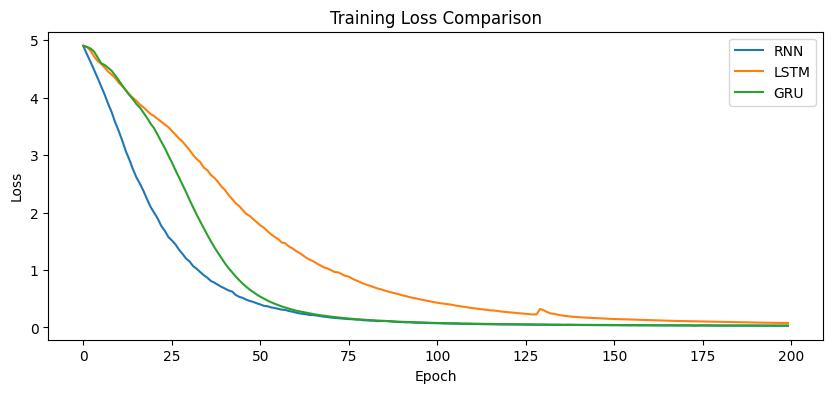

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

### 🐛 Bug fix included:
If the predicted index doesn't map to a word (e.g. padding index 0), we now **skip / stop** instead of appending a blank `""` word.

In [8]:
def generate_text(model, seed_text, next_words=10):  # ✅ TASK 5: default 5 -> 10
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        # 🐛 bug fix: stop instead of appending an empty word if nothing matched
        if output_word == "":
            break

        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

### ✅ Task 5: Generating 10 words instead of 5

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning models can capture grammar syntax and semantic meaning from large
LSTM: deep learning models can capture grammar syntax and semantic meaning from large
GRU : deep learning models can capture grammar syntax and semantic meaning from large


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- With a **larger embedding dimension (64)**, **more hidden units (128)**, and **more training epochs (200)**, all three models get more capacity and time to fit the (still small) custom corpus, typically lowering training loss further compared to the original tiny settings
- This notebook helps students understand **sequence modeling mathematically and practically**